In [26]:
import os # to deal with files
import gdown # to download from google drive
import zipfile # to unzip

# download demonstration data from Google Drive
dataset_path = "pusht_cchi_v7_replay.zarr.zip"
extracted_dataset_path = "pusht_cchi_v7_replay.zarr"  # Path to extracted dataset

if not os.path.isfile(dataset_path):
    id = "1KY1InLurpMvJDRb14L9NlXT_fEsCvVUq&confirm=t"
    gdown.download(id=id, output=dataset_path, quiet=False)

# Extract the dataset if it hasn't been extracted yet
if not os.path.isdir(extracted_dataset_path):
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_dataset_path)

In [27]:
import zarr # to load the dataset
import numpy as np
import torch

def create_sample_indices(
        episode_ends:np.ndarray, sequence_length:int,
        pad_before: int=0, pad_after: int=0):
    indices = list()
    for i in range(len(episode_ends)):
        start_idx = 0
        if i > 0:
            start_idx = episode_ends[i-1]
        end_idx = episode_ends[i]
        episode_length = end_idx - start_idx

        min_start = -pad_before
        max_start = episode_length - sequence_length + pad_after

        # range stops one idx before end
        for idx in range(min_start, max_start+1):
            buffer_start_idx = max(idx, 0) + start_idx
            buffer_end_idx = min(idx+sequence_length, episode_length) + start_idx
            start_offset = buffer_start_idx - (idx+start_idx)
            end_offset = (idx+sequence_length+start_idx) - buffer_end_idx
            sample_start_idx = 0 + start_offset
            sample_end_idx = sequence_length - end_offset
            indices.append([
                buffer_start_idx, buffer_end_idx,
                sample_start_idx, sample_end_idx])
    indices = np.array(indices)
    return indices


def sample_sequence(train_data, sequence_length,
                    buffer_start_idx, buffer_end_idx,
                    sample_start_idx, sample_end_idx):
    result = dict()
    for key, input_arr in train_data.items():
        sample = input_arr[buffer_start_idx:buffer_end_idx]
        data = sample
        if (sample_start_idx > 0) or (sample_end_idx < sequence_length):
            data = np.zeros(
                shape=(sequence_length,) + input_arr.shape[1:],
                dtype=input_arr.dtype)
            if sample_start_idx > 0:
                data[:sample_start_idx] = sample[0]
            if sample_end_idx < sequence_length:
                data[sample_end_idx:] = sample[-1]
            data[sample_start_idx:sample_end_idx] = sample
        result[key] = data
    return result

# normalize data
def get_data_stats(data):
    data = data.reshape(-1,data.shape[-1])
    stats = {
        'min': np.min(data, axis=0),
        'max': np.max(data, axis=0)
    }
    return stats

def normalize_data(data, stats):
    # nomalize to [0,1]
    ndata = (data - stats['min']) / (stats['max'] - stats['min'])
    # normalize to [-1, 1]
    ndata = ndata * 2 - 1
    return ndata

def unnormalize_data(ndata, stats):
    ndata = (ndata + 1) / 2
    data = ndata * (stats['max'] - stats['min']) + stats['min']
    return data

# dataset
class PushTStateDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path,
                 pred_horizon, obs_horizon, action_horizon):

        # read from zarr dataset
        dataset_root = zarr.open(dataset_path, mode='r')
        # All demonstration episodes are concatinated in the first dimension N
        train_data = {
            # (N, action_dim)
            'action': dataset_root['data']['action'][:],
            # (N, obs_dim)
            'obs': dataset_root['data']['state'][:]
        }
        # Marks one-past the last index for each episode
        episode_ends = dataset_root['meta']['episode_ends'][:]

        # compute start and end of each state-action sequence
        # also handles padding
        indices = create_sample_indices(
            episode_ends=episode_ends,
            sequence_length=pred_horizon,
            # add padding such that each timestep in the dataset are seen
            pad_before=obs_horizon-1,
            pad_after=action_horizon-1)

        # compute statistics and normalized data to [-1,1]
        stats = dict()
        normalized_train_data = dict()
        for key, data in train_data.items():
            stats[key] = get_data_stats(data)
            normalized_train_data[key] = normalize_data(data, stats[key])

        self.indices = indices
        self.stats = stats
        self.normalized_train_data = normalized_train_data
        self.pred_horizon = pred_horizon
        self.action_horizon = action_horizon
        self.obs_horizon = obs_horizon

    def __len__(self):
        # all possible segments of the dataset
        return len(self.indices)

    def __getitem__(self, idx):
        # get the start/end indices for this datapoint
        buffer_start_idx, buffer_end_idx, \
            sample_start_idx, sample_end_idx = self.indices[idx]

        # get nomralized data using these indices
        nsample = sample_sequence(
            train_data=self.normalized_train_data,
            sequence_length=self.pred_horizon,
            buffer_start_idx=buffer_start_idx,
            buffer_end_idx=buffer_end_idx,
            sample_start_idx=sample_start_idx,
            sample_end_idx=sample_end_idx
        )

        # discard unused observations
        nsample['obs'] = nsample['obs'][:self.obs_horizon,:]
        return nsample

In [28]:
from torch.utils.data import random_split

# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
#|o|o|                             observations: 2
#| |a|a|a|a|a|a|a|a|               actions executed: 8
#|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

# create dataset from file
dataset = PushTStateDataset(
    dataset_path=extracted_dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)
# save training data statistics (min, max) for each dim
stats = dataset.stats

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size  # Ensure all samples are used

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# create dataloaders
dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    num_workers=0,
    shuffle=True, # set this to False to visualize the dataset
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=False
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    num_workers=0,
    shuffle=False, # set this to False to visualize the dataset
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=False
)


# visualize data in batch
batch = next(iter(val_dataloader))
print("batch['obs'].shape:", batch['obs'].shape)
print("batch['action'].shape", batch['action'].shape)

batch['obs'].shape: torch.Size([64, 2, 5])
batch['action'].shape torch.Size([64, 16, 2])


/Users/ncorrell/Downloads/transfomer/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [29]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

t_position = torch.cat((batch["obs"][...,:-1],
                        torch.sin(batch["obs"][...,-1]).unsqueeze(-1),
                        torch.cos(batch["obs"][...,-1]).unsqueeze(-1)),
                       dim=-1)[:,:,2:].to(device)

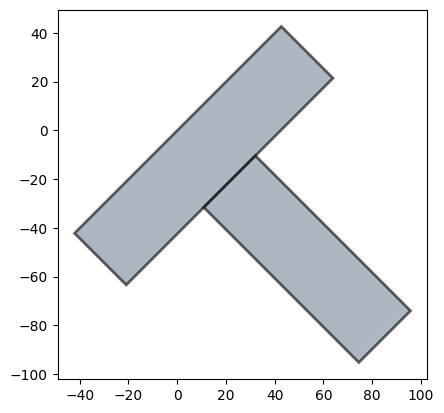

In [30]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np

def plot_tee(ax,position, angle, scale=30, color='lightslategray'):
    length = 4

    vertices1 = np.array([[-length * scale / 2, -scale],
                          [ length * scale / 2, -scale],
                          [ length * scale / 2, 0],
                          [-length * scale / 2, 0]])

    vertices2 = np.array([[-scale / 2, -scale],
                          [-scale / 2, -length * scale],
                          [ scale / 2, -length * scale],
                          [ scale / 2, -scale]])

    theta=angle
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])

    # Rotate and translate
    vertices1 = (vertices1 @ rotation_matrix.T) + position
    vertices2 = (vertices2 @ rotation_matrix.T) + position

    # Plot the T-shape
    ax.fill(*zip(*vertices1), color=color, alpha=0.6, edgecolor='black', linewidth=2)
    ax.fill(*zip(*vertices2), color=color, alpha=0.6, edgecolor='black', linewidth=2)


# Example usage
fig, ax = plt.subplots()

plot_tee(ax,position=(0.3, 0.2), angle=np.pi/4)
ax.set_aspect('equal')

/var/folders/td/d67m9t791w501d8k_8wp92280000gp/T/ipykernel_99260/196248999.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
/var/folders/td/d67m9t791w501d8k_8wp92280000gp/T/ipykernel_99260/196248999.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  [np.sin(theta),  np.cos(theta)]])


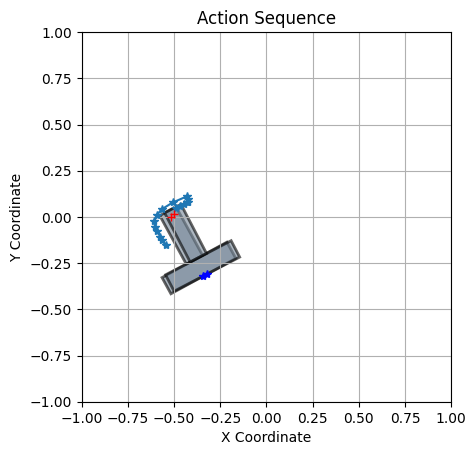

In [31]:
import matplotlib.pyplot as plt

B=54

# Assuming batch["action"][0] is a list of lists, where each inner list represents [x, y] coordinates
x_coords = [point[0] for point in batch["action"][B]]
y_coords = [point[1] for point in batch["action"][B]]


fig, ax = plt.subplots()
plt.plot(x_coords, y_coords, marker='*', linestyle='-') # actions
for i in range(batch["obs"].size(1)):
  plot_tee(ax,position=(batch["obs"][B][i][2], batch["obs"][B][i][3]), scale=0.1, angle=batch["obs"][B][i][4]*np.pi)
  plt.plot(batch["obs"][B][i][0],batch["obs"][B][i][1],'r+') # agent_x / agent_y
  plt.plot(batch["obs"][B][i][2],batch["obs"][B][i][3],'b*') # 0/0 of Tee

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Action Sequence")
plt.grid(True)
plt.xlim(-1, 1)  # Adjust limits as needed
plt.ylim(-1, 1)
plt.gca().set_aspect('equal', adjustable='box') #Equal aspect ratio
plt.show()

In [32]:
import torch
import torch.nn as nn

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x, start):
        """
        x: (batch, seq_len, dim)
        """
        device = x.device  # Get the device from the input tensor
        batch_size, seq_len, dim = x.size()  # batch_size, seq_len, dim
        half_dim = self.dim // 2  # We divide the dim into two halves for sin/cos

        # Create a position tensor from 0 to seq_len-1
        position = torch.arange(start, start+seq_len, device=device).float()  # (seq_len,)

        # Create div_term for sinusoidal encoding
        div_term = torch.exp(torch.arange(0, half_dim, 1, device=device).float() * -(math.log(10000.0) / half_dim))  # (half_dim,)

        # Calculate sinusoidal embeddings: sin and cos
        pe = position.unsqueeze(1) * div_term.unsqueeze(0)  # (seq_len, half_dim)
        pe = torch.cat((pe.sin(), pe.cos()), dim=-1)  # (seq_len, dim)

        # Expand to match batch size
        pe = pe.unsqueeze(0)  # (1, seq_len, dim)
        pe = pe.expand(batch_size, -1, -1)  # (batch_size, seq_len, dim)

        return pe.to(device)  # Make sure it's on the same device as x

In [33]:
import torch
import torch.nn as nn

class PushTTransformer(nn.Module):
    def __init__(self, d_model=512, nhead=4, num_layers=4, dropout=0.1, betas=(0.9, 0.95), weight_decay=0.01):
        super().__init__()

        # Embedding layers for tool positions and T's position
        self.tool_embed = nn.Linear(2, d_model)  # (x, y) → d_model
        self.t_embed = nn.Linear(4, d_model)     # (x_T, y_T, sinθ, cosθ) → d_model

        # Position embedding
        self.pe = SinusoidalPosEmb(d_model)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,dropout=dropout)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output layer to predict next (x, y) positions
        self.fc_out = nn.Linear(d_model, 2)

    def forward(self, tool_past, t_position, tool_future=None):
      batch_size = tool_past.shape[0]
      device = tool_past.device

      # Encoder: Process past tool positions and T's position
      tool_past_emb = self.tool_embed(tool_past[:,-1,:])  # (batch, d_model)
      tool_past_emb = tool_past_emb.unsqueeze(1) # (batch, 1, d_model)

      tool_past_emb += self.pe(tool_past_emb, 0)  # Add positional encoding
      tool_past_emb = tool_past_emb.permute(1, 0, 2)  # (1, batch, d_model)

      # T's position (sequence)
      t_emb = self.t_embed(t_position[:,-1,:])  # (batch, t_seq_len, d_model), e.g., (batch, 1, d_model)
      t_emb = t_emb.unsqueeze(1)
      t_emb = t_emb.permute(1, 0, 2)  # (t_seq_len, batch, d_model), e.g., (1, batch, d_model)

      memory_input = t_emb # (1, batch, d_model)
      memory = self.encoder(memory_input)  # (1, batch, d_model)

      if tool_future is not None:
          # Training mode: Use teacher forcing with the ground truth sequence
          tool_future_emb = self.tool_embed(tool_future[:, :7, :])  # (batch, 7, d_model)
          tool_future_emb += self.pe(tool_future_emb,1)
          tool_future_emb = tool_future_emb.permute(1, 0, 2)  # (7, batch, d_model)
          seq_len = tool_future_emb.shape[0]  # 7
          causal_mask = torch.triu(torch.ones(seq_len+1, seq_len+1, device=device), diagonal=1).bool() # tool_past + tool_future

          path = torch.cat([tool_past_emb, tool_future_emb], dim=0)

          output = self.decoder(path, memory.expand(seq_len+1, -1, -1), tgt_mask=causal_mask)
          output = self.fc_out(output).permute(1, 0, 2)  # (batch, 16, 2)
          return output[:,:,:]
      else:
          # Inference mode: Generate autoregressively
          current_pos = tool_past[:, -1:, :]  # Start with the last tool position (batch, 1, 2)
          tool_future_emb = self.tool_embed(current_pos)  # (batch, 1, d_model)
          tool_future_emb += self.pe(tool_future_emb,0)
          tool_future_emb = tool_future_emb.permute(1, 0, 2)  # (1, batch, d_model)
          generated = []

          for step in range(8):  # Generate 8 steps
              seq_len = tool_future_emb.shape[0]  # Current sequence length
              # Create a causal mask: upper triangle is blocked
              causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(device)
              # Pass the sequence and mask to the decoder

              output = self.decoder(tool_future_emb, memory.expand(seq_len, -1, -1), tgt_mask=causal_mask) # (seq_len,batch,d_model)
              # Use the last output to predict the next token
              next_pos = self.fc_out(output[-1]).unsqueeze(0) # (1,batch,d_model)
              generated.append(next_pos) # (seq_len-1,batch,d_model)
              # Append the new token to the sequence (with embeddings and positional encoding)
              next_emb = self.tool_embed(next_pos.permute(1, 0, 2)) # (batch, 1, d_model)
              next_emb += self.pe(next_emb,seq_len)[:, :1, :]  # Positional encoding for current step
              tool_future_emb = torch.cat((tool_future_emb, next_emb.permute(1,0,2)), dim=0) # (seq_len, batch, d_model)

          # Combine all generated steps
          generated = torch.cat(generated, dim=0).permute(1, 0, 2)  # (batch, 16, 2)
          return generated[:,:,:]

device = "cuda" if torch.cuda.is_available() else "cpu"

model = PushTTransformer().to(device)
epoch = 0

/var/folders/td/d67m9t791w501d8k_8wp92280000gp/T/ipykernel_99260/3934486425.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import math

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=10e-7)  # T_max is the number of iterations for the decay


for epoch in range(epoch, epoch + 100):

    # Training phase
    model.train()  # Set model to training mode
    train_loss = 0.0

    with tqdm(dataloader, desc='Training Batch', leave=False) as tepoch:
        for batch in tepoch:
            tool_past = batch['obs'][:,:,0:2].to(device)  # the last two actions
            t_position = torch.cat((batch["obs"][...,:-1],
                                    torch.sin(batch["obs"][...,-1]).unsqueeze(-1),
                                    torch.cos(batch["obs"][...,-1]).unsqueeze(-1)),
                                   dim=-1)[:,:,2:].to(device)
            tool_future = batch['action'].to(device)  # the future actions

            # Training step
            optimizer.zero_grad()
            pred_future = model(tool_past, t_position, tool_future)
            loss = criterion(pred_future, tool_future[:, :8, :])
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

    # Average training loss
    avg_train_loss = train_loss / len(dataloader)

    # Validation phase
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0

    with torch.no_grad():  # No gradients needed for validation
        for batch in val_dataloader:
            tool_past = batch['obs'][:,:,0:2].to(device)  # the last two actions
            t_position = torch.cat((batch["obs"][...,:-1],
                                    torch.sin(batch["obs"][...,-1]).unsqueeze(-1),
                                    torch.cos(batch["obs"][...,-1]).unsqueeze(-1)),
                                   dim=-1)[:,:,2:].to(device)
            tool_future = batch['action'].to(device)  # the future actions

            # Validation step
            pred_future = model(tool_past, t_position, tool_future)
            loss = criterion(pred_future, tool_future[:, :8, :])
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)     # Average validation loss

    scheduler.step() # Step the scheduler 

    # Print stats for the epoch
    print(f"Epoch: {epoch} | Train Loss: {avg_train_loss * 1000:.4f} | Validation Loss: {avg_val_loss * 1000:.4f}")

    # Print current learning rate
    for param_group in optimizer.param_groups:
        print(f"Current Learning Rate: {param_group['lr']:.8f}")

In [79]:
import gymnasium as gym
from gymnasium import spaces
from typing import Tuple, Sequence, Dict, Union, Optional
import pymunk
from pymunk.vec2d import Vec2d
import shapely.geometry as sg
import skimage.transform as st
from skvideo.io import vwrite
from IPython.display import Video
import gdown
import os

def pymunk_to_shapely(body, shapes):
    geoms = list()
    for shape in shapes:
        if isinstance(shape, pymunk.shapes.Poly):
            verts = [body.local_to_world(v) for v in shape.get_vertices()]
            verts += [verts[0]]
            geoms.append(sg.Polygon(verts))
        else:
            raise RuntimeError(f'Unsupported shape type {type(shape)}')
    geom = sg.MultiPolygon(geoms)
    return geom

# env
class PushTEnv(gym.Env):
    metadata = {"render.modes": ["rgb_array"], "video.frames_per_second": 10}
    reward_range = (0., 1.)

    def __init__(self,
            legacy=False,
            block_cog=None, damping=None,
            render_action=True,
            render_size=96,
            reset_to_state=None
        ):
        self._seed = None
        self.n_contact_points = 0
        self.seed()
        self.window_size = ws = 512  # The size of the PyGame window
        self.render_size = render_size
        self.sim_hz = 100
        # Local controller params.
        self.k_p, self.k_v = 100, 20    # PD control.z
        self.control_hz = self.metadata['video.frames_per_second']
        # legcay set_state for data compatiblity
        self.legacy = legacy

        # agent_pos, block_pos, block_angle
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0], dtype=np.float64),
            high=np.array([ws,ws,ws,ws,np.pi*2], dtype=np.float64),
            shape=(5,),
            dtype=np.float64
        )

        # positional goal for agent
        self.action_space = spaces.Box(
            low=np.array([0,0], dtype=np.float64),
            high=np.array([ws,ws], dtype=np.float64),
            shape=(2,),
            dtype=np.float64
        )

        self.block_cog = block_cog
        self.damping = damping
        self.render_action = render_action

        self.space = None
        self.render_buffer = None
        self.latest_action = None
        self.reset_to_state = reset_to_state

    def reset(self):
        seed = self._seed
        self._setup()
        if self.block_cog is not None:
            self.block.center_of_gravity = self.block_cog
        if self.damping is not None:
            self.space.damping = self.damping

        # use legacy RandomState for compatiblity
        state = self.reset_to_state
        if state is None:
            rs = np.random.RandomState(seed=seed)
            state = np.array([
                rs.randint(50, 450), rs.randint(50, 450),
                rs.randint(100, 400), rs.randint(100, 400),
                rs.randn() * 2 * np.pi - np.pi
                ])
        self._set_state(state)

        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def step(self, action):
        dt = 1.0 / self.sim_hz
        self.n_contact_points = 0
        n_steps = self.sim_hz // self.control_hz
        if action is not None:
            self.latest_action = action
            for i in range(n_steps):
                # Step PD control.
                # self.agent.velocity = self.k_p * (act - self.agent.position)    # P control works too.
                acceleration = self.k_p * (action - self.agent.position) + self.k_v * (Vec2d(0, 0) - self.agent.velocity)
                self.agent.velocity += acceleration * dt

                # Step physics.
                self.space.step(dt)

        # compute reward
        goal_body = self._get_goal_pose_body(self.goal_pose)
        goal_geom = pymunk_to_shapely(goal_body, self.block.shapes)
        block_geom = pymunk_to_shapely(self.block, self.block.shapes)

        intersection_area = goal_geom.intersection(block_geom).area
        goal_area = goal_geom.area
        coverage = intersection_area / goal_area
        reward = np.clip(coverage / self.success_threshold, 0, 1)
        done = coverage > self.success_threshold
        terminated = done
        truncated = done

        observation = self._get_obs()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def render(self, mode=None):
        """Render the environment as RGB array."""
        if mode == 'rgb_array' or mode is None:
            return self._render_frame()
        return None

    def _render_frame(self):
        """Generate RGB array of the current environment state."""
        from skimage.draw import polygon, disk
        
        # Create empty canvas
        img = np.ones((self.render_size, self.render_size, 3), dtype=np.uint8) * 255
        
        # Scale factor from world to render
        scale = self.render_size / self.window_size
        
        def to_px(p):
            """Convert world coordinates to pixel coordinates."""
            x = int(np.clip(p[0] * scale, 0, self.render_size - 1))
            y = int(np.clip(p[1] * scale, 0, self.render_size - 1))
            return np.array([x, y], dtype=np.int32)
        
        # Draw goal T (light green) - using actual block shapes
        goal_body = self._get_goal_pose_body(self.goal_pose)
        for shape in self.block.shapes:
            verts = [goal_body.local_to_world(v) for v in shape.get_vertices()]
            pts = np.array([to_px(v) for v in verts])
            rr, cc = polygon(pts[:, 1], pts[:, 0], shape=(self.render_size, self.render_size))
            img[rr, cc] = self.goal_color
        
        # Draw current T block (slate gray) - using actual block shapes
        for shape in self.block.shapes:
            verts = [self.block.local_to_world(v) for v in shape.get_vertices()]
            pts = np.array([to_px(v) for v in verts])
            rr, cc = polygon(pts[:, 1], pts[:, 0], shape=(self.render_size, self.render_size))
            img[rr, cc] = (119, 136, 153)  # Slate gray
        
        # Draw agent (circle in blue)
        agent_pos_img = to_px(self.agent.position)
        agent_radius = max(1, int(15 * scale))
        rr, cc = disk((agent_pos_img[1], agent_pos_img[0]), agent_radius, shape=(self.render_size, self.render_size))
        img[rr, cc] = (65, 105, 225)  # Royal blue
        
        # Flip to match display orientation
        img = np.flipud(img)
        
        return img
    def _get_obs(self):
        obs = np.array(
            tuple(self.agent.position) \
            + tuple(self.block.position) \
            + (self.block.angle % (2 * np.pi),))
        return obs

    def _get_goal_pose_body(self, pose):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (50, 100))
        body = pymunk.Body(mass, inertia)
        # preserving the legacy assignment order for compatibility
        # the order here dosn't matter somehow, maybe because CoM is aligned with body origin
        body.position = pose[:2].tolist()
        body.angle = pose[2]
        return body

    def _get_info(self):
        n_steps = self.sim_hz // self.control_hz
        n_contact_points_per_step = int(np.ceil(self.n_contact_points / n_steps))
        info = {
            'pos_agent': np.array(self.agent.position),
            'vel_agent': np.array(self.agent.velocity),
            'block_pose': np.array(list(self.block.position) + [self.block.angle]),
            'goal_pose': self.goal_pose,
            'n_contacts': n_contact_points_per_step}
        return info

    def close(self):
        """Close the environment."""
        pass

    def seed(self, seed=None):
        if seed is None:
            seed = np.random.randint(0,25536)
        self._seed = seed
        self.np_random = np.random.default_rng(seed)

    def _handle_collision(self, arbiter, space, data):
        self.n_contact_points += len(arbiter.contact_point_set.points)

    def _set_state(self, state):
        if isinstance(state, np.ndarray):
            state = state.tolist()
        pos_agent = state[:2]
        pos_block = state[2:4]
        rot_block = state[4]
        self.agent.position = pos_agent
        if self.legacy:
            # for compatiblity with legacy data
            self.block.position = pos_block
            self.block.angle = rot_block
        else:
            self.block.angle = rot_block
            self.block.position = pos_block

        # Run physics to take effect
        self.space.step(1.0 / self.sim_hz)

    def _set_state_local(self, state_local):
        agent_pos_local = state_local[:2]
        block_pose_local = state_local[2:]
        tf_img_obj = st.AffineTransform(
            translation=self.goal_pose[:2],
            rotation=self.goal_pose[2])
        tf_obj_new = st.AffineTransform(
            translation=block_pose_local[:2],
            rotation=block_pose_local[2]
        )
        tf_img_new = st.AffineTransform(
            matrix=tf_img_obj.params @ tf_obj_new.params
        )
        agent_pos_new = tf_img_new(agent_pos_local)
        new_state = np.array(
            list(agent_pos_new[0]) + list(tf_img_new.translation) \
                + [tf_img_new.rotation])
        self._set_state(new_state)
        return new_state

    def _setup(self):
        self.space = pymunk.Space()
        self.space.gravity = 0, 0
        self.space.damping = 0
        #self.teleop = False
        self.render_buffer = list()

        # Add walls.
        walls = [
            self._add_segment((5, 506), (5, 5), 2),
            self._add_segment((5, 5), (506, 5), 2),
            self._add_segment((506, 5), (506, 506), 2),
            self._add_segment((5, 506), (506, 506), 2)
        ]
        self.space.add(*walls)

        # Add agent, block, and goal zone.
        self.agent = self.add_circle((256, 400), 15)
        self.block = self.add_tee((256, 300), 0)
        self.goal_color = (144, 238, 144)  # Light green RGB tuple
        self.goal_pose = np.array([256,256,np.pi/4])  # x, y, theta (in radians)

        # Add collision handeling
        self.n_contact_points = 0

        self.max_score = 50 * 100
        self.success_threshold = 0.95    # 95% coverage.

    def _add_segment(self, a, b, radius):
        shape = pymunk.Segment(self.space.static_body, a, b, radius)
        shape.color = (200, 200, 200)  # Light gray RGB
        return shape

    def add_circle(self, position, radius):
        body = pymunk.Body(body_type=pymunk.Body.KINEMATIC)
        body.position = position
        body.friction = 1
        shape = pymunk.Circle(body, radius)
        shape.color = (65, 105, 225)  # Royal blue RGB
        self.space.add(body, shape)
        return body

    def add_box(self, position, height, width):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (height, width))
        body = pymunk.Body(mass, inertia)
        body.position = position
        shape = pymunk.Poly.create_box(body, (height, width))
        shape.color = (119, 136, 153)  # Light slate gray RGB
        self.space.add(body, shape)
        return body

    def add_tee(self, position, angle, scale=30, color='LightSlateGray', mask=pymunk.ShapeFilter.ALL_MASKS()):
        mass = 1
        length = 4
        vertices1 = [(-length*scale/2, scale),
                                 ( length*scale/2, scale),
                                 ( length*scale/2, 0),
                                 (-length*scale/2, 0)]
        inertia1 = pymunk.moment_for_poly(mass, vertices=vertices1)
        vertices2 = [(-scale/2, scale),
                                 (-scale/2, length*scale),
                                 ( scale/2, length*scale),
                                 ( scale/2, scale)]
        inertia2 = pymunk.moment_for_poly(mass, vertices=vertices1)
        body = pymunk.Body(mass, inertia1 + inertia2)
        shape1 = pymunk.Poly(body, vertices1)
        shape2 = pymunk.Poly(body, vertices2)
        # shape.color removed - no rendering
        # shape.color removed - no rendering
        shape1.filter = pymunk.ShapeFilter(mask=mask)
        shape2.filter = pymunk.ShapeFilter(mask=mask)
        body.center_of_gravity = (shape1.center_of_gravity + shape2.center_of_gravity) / 2
        body.position = position
        body.angle = angle
        body.friction = 1
        self.space.add(body, shape1, shape2)
        return body

In [80]:
# 0. create env object
env = PushTEnv()

# 1. seed env for initial state.
# Seed 0-200 are used for the demonstration dataset.
env.seed(1000)

# 2. must reset before use
obs, _ = env.reset()

# 3. 2D positional action space [0,512]
action = env.action_space.sample()

# 4. Standard gym step method
obs, reward, terminated, truncated, info = env.step(action)

# prints and explains each dimension of the observation and action vectors
with np.printoptions(precision=4, suppress=True, threshold=5):
    print("Obs: ", repr(obs))
    print("Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]")
    print("Action: ", repr(action))
    print("Action:   [target_agent_x, target_agent_y]")

Obs:  array([149.4413, 201.5012, 292.    , 351.    ,   2.9196])
Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]
Action:  array([179.0781, 393.2655])
Action:   [target_agent_x, target_agent_y]


Eval PushTStateEnv: 201it [00:01, 188.48it/s, reward=0.937]                          


Score: 0.944610634182985


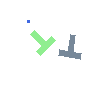

In [86]:
import collections
import imageio.v2 as imageio
from IPython.display import Image, display

# Limit environment interaction to 200 steps before termination
max_steps = 200
env = PushTEnv()
# Use a seed >200 to avoid initial states seen in the training dataset
env.seed(42)

# Get first observation
obs, info = env.reset()

# Keep a queue of last 2 steps of observations
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

# Save visualization and rewards
imgs = [env.render(mode='rgb_array')]
rewards = []
done = False
step_idx = 0

with tqdm(total=max_steps, desc="Eval PushTStateEnv") as pbar:
    while not done:
        B = 1  # Batch size

        # Stack the last obs_horizon (2) number of observations
        obs_seq = np.stack(obs_deque)
        # Normalize observation
        nobs = normalize_data(obs_seq, stats=stats['obs'])
        # Device transfer
        nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)

        # Prepare inputs for the transformer model
        tool_past = nobs[:, :2]  # Last two tool positions (x, y)
        t_position = torch.cat(
            (nobs[:, 2:-1],  # x_T, y_T
             torch.sin(nobs[:, -1]).unsqueeze(-1),
             torch.cos(nobs[:, -1]).unsqueeze(-1)),
            dim=-1
        )  # T's position (x_T, y_T, sinθ, cosθ)

        tool_past = tool_past.unsqueeze(0)  # Add batch dim (1, 2, 2)
        t_position = t_position.unsqueeze(0)  # Add batch dim (1, 4)

        # Infer action using the transformer
        with torch.no_grad():
            action_pred = model(tool_past, t_position)

        # Unnormalize action
        action_pred = action_pred.cpu().numpy()[0]
        action_pred = unnormalize_data(action_pred, stats=stats['action'])

        # Only take action_horizon number of actions
        start = obs_horizon - 1
        end = start + action_horizon
        action = action_pred[start:end, :]  # (action_horizon, action_dim)

        # Execute action_horizon number of steps without replanning
        for i in range(len(action)):
            # Stepping env
            obs, reward, done, _, info = env.step(action[i])
            # Save observations
            obs_deque.append(obs)
            # Save rewards and visualization
            rewards.append(reward)
            imgs.append(env.render(mode='rgb_array'))

            # Update progress bar
            step_idx += 1
            pbar.update(1)
            pbar.set_postfix(reward=reward)
            if step_idx > max_steps:
                done = True
            if done:
                break

# Print out the maximum target coverage
print('Score:', max(rewards))

# Visualize (default: GIF, no FFmpeg required)
valid_imgs = [im for im in imgs if isinstance(im, np.ndarray) and im.ndim == 3 and im.shape[-1] == 3]
if len(valid_imgs) == 0:
    raise RuntimeError('No valid frames were produced by env.render().')

imageio.mimsave('vis.gif', valid_imgs, duration=0.08)
display(Image(filename='vis.gif',width=300,height=300))